# Inside the network: where style actually lives

This notebook opens up the encoder used by the style-transfer model and looks at what it
sees. It supports the central claim of the AdaIN paper:

> The **spatial arrangement** of a VGG feature map carries the image's *content*.
> The **per-channel mean and standard deviation** of that same feature map carry its *style*.

If that is true, then stylising an image should leave its feature *layout* recognisable
while replacing its feature *statistics* with those of the style image. We check both halves
below, using the project's own frozen VGG-19 encoder.

In [1]:
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

ROOT = Path.cwd()
NST = ROOT / "NST_Code"
sys.path.insert(0, str(NST))          # so `from utils.models import ...` resolves

from utils.models import VGGEncoder
from utils.utils import calc_mean_std

EXAMPLES = NST / "examples"
VGG_WEIGHTS = NST / "vgg_normalised.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = 512

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

encoder = VGGEncoder(str(VGG_WEIGHTS)).to(device).eval()

print("Using device:", device)
print("Encoder layers kept:", len(list(encoder.vgg.children())), "(truncated at relu4_1)")

Using device: cpu
Encoder layers kept: 31 (truncated at relu4_1)


## Helpers

`extract_features` returns the four taps the model uses: `relu1_1`, `relu2_1`, `relu3_1`
and `relu4_1`. The first three are used only for the style loss during training; `relu4_1`
is where AdaIN itself operates.

`activation_map` averages a feature map over its channels and rescales it to `[0, 1]`, so it
can be viewed as a greyscale image.

In [2]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    return image, tensor


def extract_features(tensor):
    with torch.no_grad():
        h1, h2, h3, h4 = encoder(tensor)
    return {"relu1_1": h1, "relu2_1": h2, "relu3_1": h3, "relu4_1": h4}


def activation_map(feature_tensor):
    activation = feature_tensor[0].mean(dim=0).detach().cpu()
    activation = activation - activation.min()
    activation = activation / (activation.max() + 1e-8)
    return activation

## 1. Encode the images

One photograph and two stylised versions of it. All three share the same underlying subject,
so any difference in their features is caused by style alone.

In [3]:
image_paths = {
    "Original photograph": EXAMPLES / "portrait.jpg",
    "Stylised - graphite": EXAMPLES / "stylized_portrait_sketch.jpg",
    "Stylised - brushstrokes": EXAMPLES / "stylized_portrait_brushstrokes.jpg",
}

image_bank = {}
feature_bank = {}

for name, path in image_paths.items():
    image, tensor = load_image(path)
    image_bank[name] = image
    feature_bank[name] = extract_features(tensor)

for name, features in feature_bank.items():
    shapes = {layer: tuple(feature.shape) for layer, feature in features.items()}
    print(name)
    for layer, shape in shapes.items():
        print(f"   {layer:8} {shape}")
    print()

Original photograph
   relu1_1  (1, 64, 512, 512)
   relu2_1  (1, 128, 256, 256)
   relu3_1  (1, 256, 128, 128)
   relu4_1  (1, 512, 64, 64)

Stylised - graphite
   relu1_1  (1, 64, 512, 512)
   relu2_1  (1, 128, 256, 256)
   relu3_1  (1, 256, 128, 128)
   relu4_1  (1, 512, 64, 64)

Stylised - brushstrokes
   relu1_1  (1, 64, 512, 512)
   relu2_1  (1, 128, 256, 256)
   relu3_1  (1, 256, 128, 128)
   relu4_1  (1, 512, 64, 64)



Each block halves the spatial resolution and roughly doubles the channel count. By
`relu4_1`, a 512x512 image has become a **64x64 grid of 512-dimensional feature vectors** -
that tensor is the entire working space of the method.

## 2. Content survives stylisation

Below, each column is an image and each row is a depth in the network. Read down a column to
watch detail give way to structure; read **across** a row to compare the three images at the
same depth.

The deeper rows stay strikingly similar across all three columns. Whatever stylisation did,
it did not disturb *where things are*.

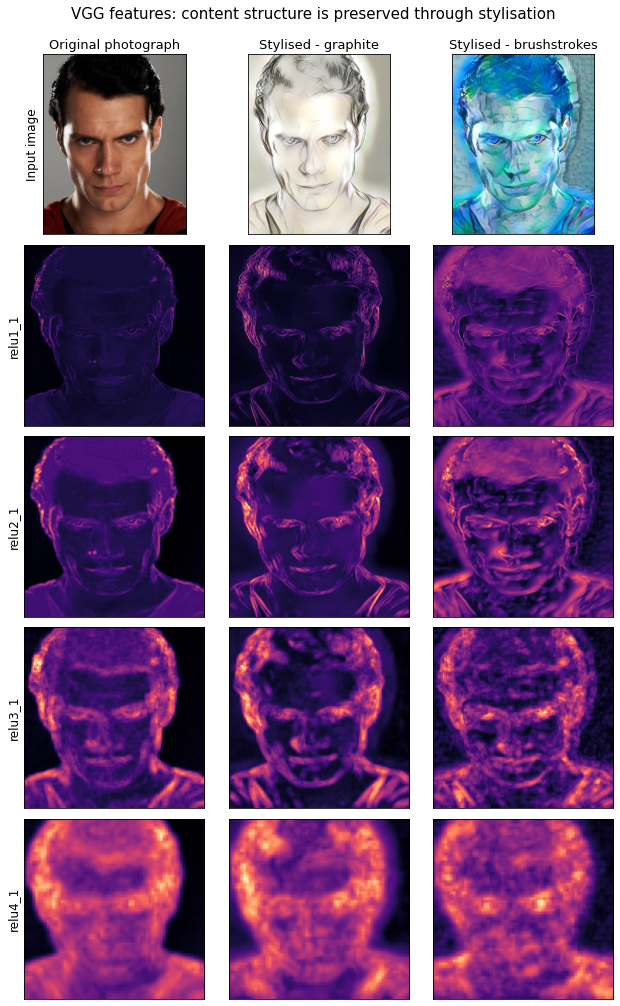

In [4]:
layers_to_show = ["relu1_1", "relu2_1", "relu3_1", "relu4_1"]
row_labels = ["Input image"] + layers_to_show
num_rows, num_cols = len(row_labels), len(image_paths)

fig, axes = plt.subplots(num_rows, num_cols,
                         figsize=(3.0 * num_cols, 2.8 * num_rows), dpi=72)

for col, name in enumerate(image_paths):
    axes[0, col].imshow(image_bank[name])
    axes[0, col].set_title(name, fontsize=13)

    for row, layer in enumerate(layers_to_show, start=1):
        axes[row, col].imshow(activation_map(feature_bank[name][layer]), cmap="magma")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=12)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("VGG features: content structure is preserved through stylisation",
             fontsize=15, y=0.995)
plt.tight_layout()
plt.show()

## 3. Style is carried by the statistics

Now the other half of the claim. For the graphite example we have all three pieces: the
**content** photograph, the **style** image it was rendered in, and the **result**.

At `relu4_1` we take the per-channel mean and standard deviation - the two numbers per
channel that AdaIN transfers - and compare them across the three images.

If style really is statistics, the result's curves should track the **style** image, not the
content photograph.

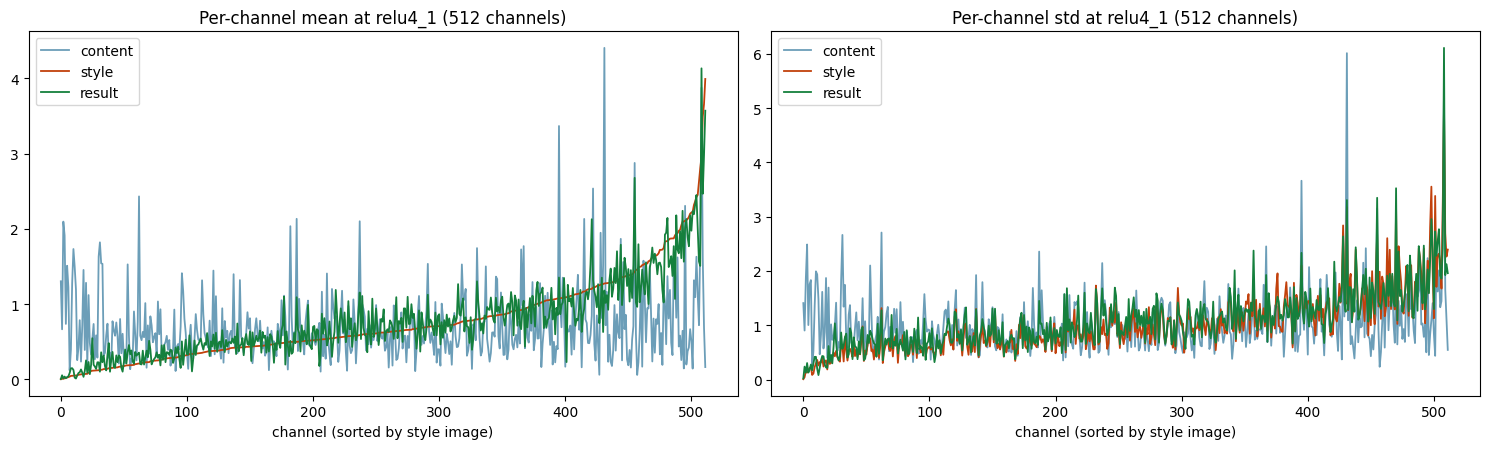

In [5]:
triplet = {
    "content": EXAMPLES / "portrait.jpg",
    "style":   EXAMPLES / "pencil_sketch.jpg",
    "result":  EXAMPLES / "stylized_portrait_sketch.jpg",
}

stats = {}
for role, path in triplet.items():
    _, tensor = load_image(path)
    with torch.no_grad():
        feat = encoder(tensor, is_test=True)      # relu4_1 only
    mean, std = calc_mean_std(feat)
    stats[role] = (mean.flatten().cpu(), std.flatten().cpu())

order = torch.argsort(stats["style"][0])          # sort channels for readability
colours = {"content": "#3B7EA1", "style": "#C2410C", "result": "#15803D"}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for idx, (stat_name, unit) in enumerate([("mean", 0), ("std", 1)]):
    for role in triplet:
        axes[idx].plot(stats[role][unit][order], label=role,
                       color=colours[role], linewidth=1.3,
                       alpha=1.0 if role != "content" else 0.75)
    axes[idx].set_title(f"Per-channel {stat_name} at relu4_1 (512 channels)")
    axes[idx].set_xlabel("channel (sorted by style image)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [6]:
# Distance between each image's relu4_1 statistics, as plain numbers.
def stat_distance(a, b):
    mean_d = torch.norm(stats[a][0] - stats[b][0]).item()
    std_d = torch.norm(stats[a][1] - stats[b][1]).item()
    return mean_d, std_d

print(f"{'pair':22} {'mean distance':>14} {'std distance':>14}")
print("-" * 52)
for a, b in [("result", "style"), ("result", "content"), ("content", "style")]:
    mean_d, std_d = stat_distance(a, b)
    print(f"{a + ' vs ' + b:22} {mean_d:14.2f} {std_d:14.2f}")

pair                    mean distance   std distance
----------------------------------------------------
result vs style                  5.48           5.13
result vs content               14.32          11.95
content vs style                15.73          12.96


The result's feature statistics sit far closer to the **style** image than to the photograph
it was made from - even though, as section 2 showed, its spatial structure is still clearly
the photograph's.

That separation is the whole method in one observation. AdaIN exploits it directly: normalise
the content features to strip their statistics, then substitute the style's mean and standard
deviation.

$$\mathrm{AdaIN}(x, y) = \sigma(y)\left(\frac{x - \mu(x)}{\sigma(x)}\right) + \mu(y)$$

No parameters are learned in that step. It is arithmetic on the 512 numbers we just plotted -
which is exactly why an unseen style image works on the first try.